### **Neural Network from scratch using only NumPy**

This is extension of the first version of the same project, where I aim to implement scalable approach in making NN /w Numpy Only.

#### Goals:

1) Remove hard-coded parts of the code

2) Ensure input is always handled as (batch_size, n_features)

3) Implement full backpropagation with layer-wise gradient computation

4) Implement **loss** (*Binary Cross Entropy*) with __gradient descent__ optimization

5) Tracking the change of **loss** function through the epochs of learning

6) Apply the network to classification dataset (https://www.kaggle.com/datasets/youssefahmed2612/coffee-roasting)



In [52]:
import os
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd

#### Load dataset "coffee roast.csv"

In [53]:
current_directory = os.getcwd()
print(current_directory)

c:\Users\Admin\ML-concepts\NeuralNetwork\Project


Check if dataset is in child dirs:

In [54]:
for root,dirs,files in os.walk(current_directory):
    for dir in dirs:
        if dir =='Datasets'.casefold() or dir =='dataset':
            print(f'Dir. found')
# No dir named 'dataset' here, go up to parent directory

In [55]:
parent_directory = Path(current_directory).parent
print(parent_directory)

# traverse from here

for root,dirs,files in os.walk(parent_directory):
    for dir in dirs:
        if dir.startswith('datasets'):
            dir_path = os.path.join(root,dir)
            for file in os.listdir(dir_path):
                if file.startswith('Coffe'):
                    file_path = os.path.join(dir_path,file)

c:\Users\Admin\ML-concepts\NeuralNetwork


In [56]:
# Helper functions

def to_numpy(non_array):
    return non_array.to_numpy()

def check_shape(input_data):
    if len(input_data.shape)!=2:
        print(f"Expected 2D, got {len(input_data.shape)}D")

def check_y_shape(y):
    if y.ndim ==1:
        y = y.reshape(y.shape[0],1)
    return y

    


In [57]:
dataset = pd.read_csv(file_path)
dataset.head()

,Temprature,Duration,Target
0,185.32,12.69,1
1,259.92,11.87,0
2,231.01,14.41,0
3,175.37,11.72,0
4,187.12,14.13,1


In [58]:
X = dataset.iloc[:,0:2] 
y = dataset.iloc[:,-1]

X = to_numpy(X)
y = to_numpy(y)


In [59]:
print(X.shape)
print(y.shape)

(200, 2)
(200,)


---

Model architecture idea:

**Dense** layers are idenepndant of eachother - > They initialize coefficients based on input **shape** and **units** (neurons in the layer)


They are connected with **forward** - > takse Z from Dense, apply  **activation** -> pass to another Dense as **a_in**

- layer1.dense(X input vector...) -> w1,b1 -- **forward** -> activation -> return A1 

- A1 becomes input of the next dense layer (layer2)..

In [60]:
class Sigmoid:
    def sigmoid_activate(self,X):
        return 1/(1 + np.exp(-X))
activation = Sigmoid()

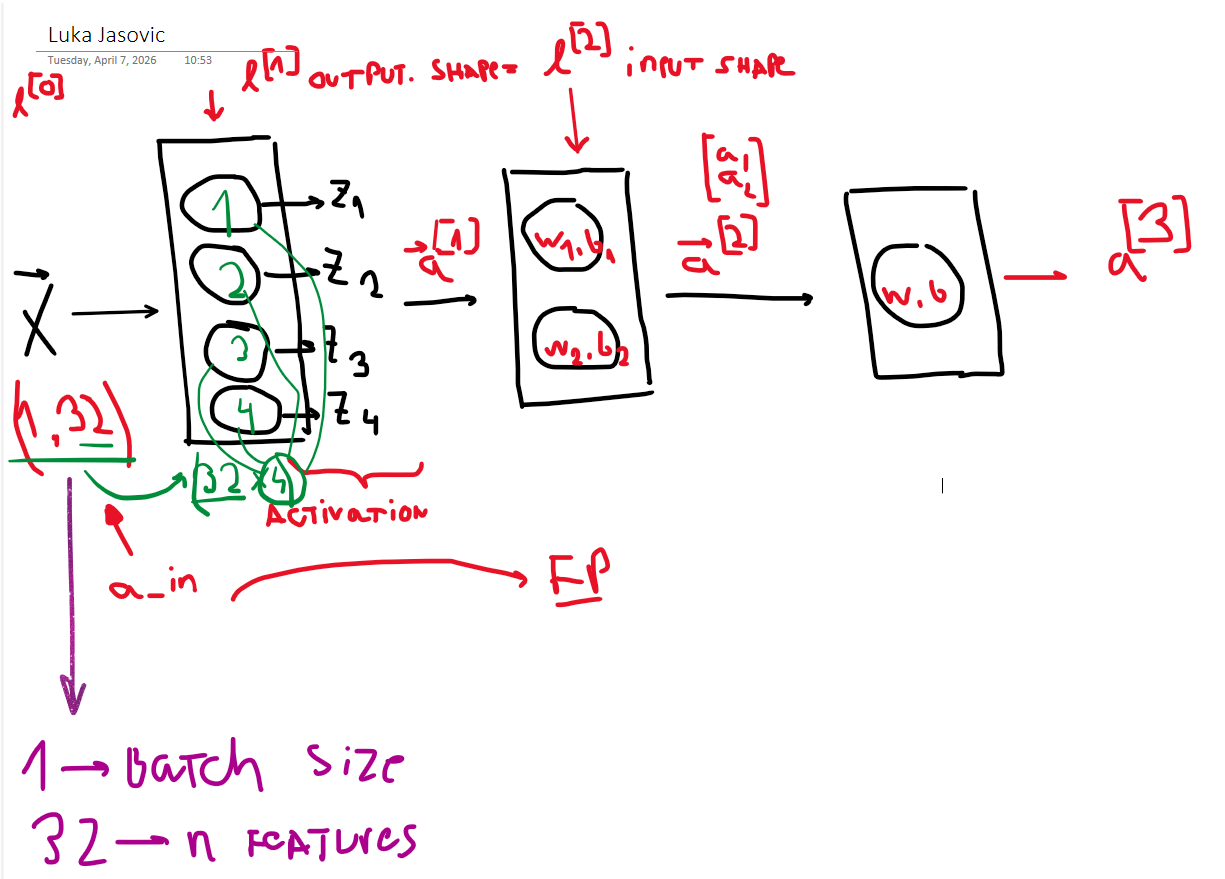

In dense layer here, calculated Z is pure linear output and it will be ignored.

The main objective of the dense layer here is coefficients initialization based on the input.

Forward propagation uses the initialized coefficients and calculates the Z and applying linear transformation to the output.



In [61]:
class layers():
    def __init__(self):
        pass
    def Dense(self,input_dim,neurons,activation,first_layer=False):
   
        self.activation = activation # Sigmoid only for now
        
        # normal distribution for W , mean 0 / std 0.05
        # zeros for b

        W = np.random.normal(loc=0,scale=0.05,size=(input_dim,neurons))
        b = np.zeros(neurons)
        self.W = W
        self.b = b
        self.layer_weights = {'W':self.W,'b':self.b} 
    
        """

        Z odavde ne koristim, jer forward_prop racuna novi Z
        # Z = np.matmul(a_in,self.W) + self.b
        # self.Z = Z
        # return self.Z

        """

    def forward(self,A_in):
        
        Z = np.matmul(A_in,self.W) + self.b 
        self.Z = Z
        A = self.activation.sigmoid_activate(self.Z)
        self.A = A
        self.storage = {'A_prev':A_in,'Z':self.Z} #storing A_prev - > will be used to compute the gradients in backpropagation A[3] = self.A , A[2] = A_in
        return A
    
    
    def backpropagate_output(self,a_out,y):
        if y.ndim == 1:
            y = y.reshape(y.shape[0],1) 
        m,_ = y.shape

        # calculate the loss in the output layer

        L = -(y*np.log(a_out)+(1-y)*np.log(1-a_out)) # one sample
        cost = (1/m)*sum(L) # for batch/dataset

        dZ3 = -(1/m) * ((y / a_out) - ((1 - y) / (1 - a_out))) * (np.exp(-self.Z) / (1 + np.exp(-self.Z))**2)
        
        dW3 = (1/m)*np.matmul(self.storage['A_prev'].T,dZ3) #Transpose input to (200,2) -> (2,200) to match the inner dims.
        #print(f"dW3 shape: -> {dW3.shape}") #(2,1)
        
        db3 = (1/m)*np.sum(dZ3,axis=0) 

        self.dW3 = dW3
        self.db3 = db3

        dA2 = np.matmul(dZ3,self.list_coef['W'].T)
        return dA2
            
    def backpropagate_hidden(self,dA_in):
        m = dA_in.shape[0]

        dZ2 = dA_in * self.A*(1-self.A)

        dW2 = (1/m) * np.matmul(self.storage['A_prev'].T,dZ2)

        db2 = (1/m) * np.sum(dZ2,axis=0)

        dA1 = np.matmul(dZ2,(self.list_coef['W'].T))

        dZ1 = dA1 * self.storage['A_prev'] * (1 - self.storage['A_prev'])

        dW1 = (1/m) * np.matmul(self.storage['A_prev'].T,dZ1)

        db1 = (1/m) * np.sum(dZ1,axis=1)

        self.gradient_storage = {'W2':dW2,'b2':db2,'W1':dW1,'b1':db1}

        return dA1

### **Backpropagation**

Backpropagation is used in order to udpate the weights in Neural Network. It adjust the weights to minimize the **Loss** function. 

- I calculate the gradient (partial derivative) of the loss function for every weight, identifying how much each parameter contributed to the total error.

My initial idea was implementing __backprop__ method inside the *__layers()__* class. In order to update the previous weights, 

I must create a weights history and also a_in history. It will be stored in the layer object.


**Computational graph** - (backprop.)

J(w,b) -> A^[3] -> Z^[3] -> W^[3] -> b^[3] . . . A^[1] -> Z^[1] -> **W^[1]** -> **b^[1]**

ovde ide slika dj/da[3]..


**Sequential** 

In Keras the Sequential model is a linear stack of layers where each layer has exactly one input tensor and one output tensor


In [62]:
"""
class Sequential():
    def __init__(self):
        pass
    def flow(self,a_in,y):

        if a_in.shape[0] != y.shape[0]:
            print("Input rows must match the output rows!")
            exit()

        # instantiation of the class objects

        layer_1 = layers() # each has it's own coefficients 
        layer_2 = layers()  
        layer_3 = layers()
        
        # because of this desing, each layer requires input shape,and I must calculate A_i for previous layer
        # in order to create every subsequent layer

        layer_1.Dense(a_in,4,activation,first_layer=True)
        A1 = layer_1.forward(a_in)

        layer_2.Dense(A1,2,activation)
        A2 = layer_2.forward(A1)
       
        layer_3.Dense(A2,1,activation)
        A3 = layer_3.forward(A2)

        
        collect_layers = [layer_1,layer_2,layer_3]
        self.collect_layer = collect_layers
        
        
        #Backpropagate:

        #1) backpropagate_output takes A_output from last layer and target feature y, computes the loss and [dA3,dW3]
        #2) backpropagate_hidden takes dA3 which is corrected A3 output, and returns dA2
     
        
        dA2 = layer_3.backpropagate_output(A3,y)
        dA1 = layer_2.backpropagate_hidden(dA2)
        
        return A3

   # def summary(self):
        #print(self.coefficients)
"""

'\nclass Sequential():\n    def __init__(self):\n        pass\n    def flow(self,a_in,y):\n\n        if a_in.shape[0] != y.shape[0]:\n            print("Input rows must match the output rows!")\n            exit()\n\n        # instantiation of the class objects\n\n        layer_1 = layers() # each has it\'s own coefficients \n        layer_2 = layers()  \n        layer_3 = layers()\n\n        # because of this desing, each layer requires input shape,and I must calculate A_i for previous layer\n        # in order to create every subsequent layer\n\n        layer_1.Dense(a_in,4,activation,first_layer=True)\n        A1 = layer_1.forward(a_in)\n\n        layer_2.Dense(A1,2,activation)\n        A2 = layer_2.forward(A1)\n\n        layer_3.Dense(A2,1,activation)\n        A3 = layer_3.forward(A2)\n\n\n        collect_layers = [layer_1,layer_2,layer_3]\n        self.collect_layer = collect_layers\n\n\n        #Backpropagate:\n\n        #1) backpropagate_output takes A_output from last layer and

1. loss(y,y_hat) - single example
2. cost - loss over all training examples

---

Odavde:

In [63]:
class layers():
    def __init__(self):
        pass
    def Dense(self,input_dim,neurons,activation):
   
        self.activation = activation # Sigmoid za sada samo
        
        # normal za W /  mean=0 std=0.05
        # b zeros

        W = np.random.normal(loc=0,scale=0.05,size=(input_dim,neurons))
        b = np.zeros(neurons)
        self.W = W
        self.b = b
        self.layer_weights = {'W':self.W,'b':self.b} 
    
        """

        Z odavde ne koristim, jer forward_prop racuna novi Z
        # Z = np.matmul(a_in,self.W) + self.b
        # self.Z = Z
        # return self.Z

        """

    def forward(self,A_in):
        """
        Propagacija unapred, prvi hidden sloj kao input uzima tensor X i racuna A1
        Sledeci sloj kao input uzima output prethodnog sloja
        
        """

        Z = np.matmul(A_in,self.layer_weights['W']) + self.layer_weights['b'] 
        self.Z = Z
        A = self.activation.sigmoid_activate(self.Z)
        self.A = A
        self.storage = {'A_prev':A_in,'Z':self.Z} 

        return A
    


In [64]:
class Sequential:
    def __init__(self,input_dim,neurons:list,verbose=False):

        self.verbose=verbose
        self.neurons=neurons

        """
            Instantizacija layer objekata
        """

        layer_1 = layers()
        layer_2 = layers()  
        layer_3 = layers()

        """
            svaki layer dobija inicijalizuje svoje koeficijente W i b koji se cuvaju kao atribut objekta 
        
        """

        layer_1.Dense(input_dim,neurons[0],activation=activation)
        layer_2.Dense(neurons[0],neurons[1],activation=activation)
        layer_3.Dense(neurons[1],neurons[2],activation=activation)

        self.layer_1 = layer_1
        self.layer_2 = layer_2 
        self.layer_3 = layer_3
        self.activation=activation
        
        collect_layers = [layer_1,layer_2,layer_3]
        self.collect_layer = collect_layers

    def flow(self,a_in):

        """
        
        flow radi samo forward pass i dobija se A3 odnosno y_pred 
        
        """
        check_shape(a_in) # Proverava da li je input 2D tensor


        A1 = self.layer_1.forward(a_in)
        A2 = self.layer_2.forward(A1)
        A3 = self.layer_3.forward(A2)
        

        if self.verbose:
            print(f"{'-'*35}\nSummary of the model architecture:\nTotal number of layers: {len(list(self.neurons))}\
                  \nNumber of neurons per layer: {[self.neurons for self.neurons in self.neurons]}\
                  \nShape of the input data: {a_in.shape}\nActivation function in each layer: {self.activation}\
                  \nLayers stored /w coefficients W and b: {[(f'W_{i+1}: {layer.W}',f'b_{i+1}: {layer.b}') for i,layer in enumerate(self.collect_layer)]}")
            print(f"Output data shape: {A3.shape}\n{'-'*35}")
        return A3


In [65]:
ZZZ = Sequential(input_dim=2,neurons=[4,2,1],verbose=False)

In [66]:
class Model:
    def __init__(self,model):
        self.model = model
        self.model_layers = model.collect_layer
    def fit(self,X,y,epochs:int,alpha):
        m,n = X.shape
        self.m = m

        # y shape (m,)
        y = check_y_shape(y)

        """
            iteracija kroz jednu epohu treniranja modela:
            1. Ceo dataset prolazi kroz forward pass, racuna se cost
            2. Backward pass racuna gradijente i updejtuje koeficijente
            3. nove vrednosti W i b kao i cost se cuvaju

        """

        history = [] # Prazna lista za pracenje smanjivanja cost(w,b)
        
        for i in range(1,epochs+1):

            A_out = self.model.flow(X) # odradjen forward pass, dobijen je A^[3]

            L =  -(y*np.log(A_out)+(1-y)*np.log(1-A_out)) 
            current_cost = (1/X.shape[0]) * np.sum(L)
            history.append({'epoch':i,'current_cost':current_cost})

           # Pristupanje sacuvanim W i B vrednostima koeficijenata kroz self.model_layers[i].layer_weights          

     

            # Implementiram jos jednu petlju kako bih vrsio iteraciju od poslednjeg do prvog sloja i izbegao hard-codovanje derivata
            # Unutrasnja petlja vrsi iteraciju od 3 -> 1 sloju i racuna gradijente respektivno od [dW3 db3] do [dW1 db1]
           
            for j,layer in enumerate(self.model_layers[::-1]):
                if j ==0: # 3. sloj 
                    dZ = -(1/m) * ((y / A_out) - ((1 - y) / (1 - A_out))) * (np.exp(layer.storage['Z']) / (1 + np.exp(layer.storage['Z']))**2)
                    dW= np.matmul(layer.storage['A_prev'].T,dZ)
                    db =np.sum(dZ,axis=0)
                    dA = np.matmul(dZ,layer.layer_weights['W'].T) 
                    A_2 = layer.storage['A_prev'] 
                    layer.dW = dW
                    layer.db = db
                elif j == 1: # 2. sloj
                    dZ = dA * A_2*(1-A_2)
                    dW = np.matmul(layer.storage['A_prev'].T,dZ) 
                    db =np.sum(dZ,axis=0)
                    dA = np.matmul(dZ,layer.layer_weights['W'].T)
                    A_1 = layer.storage['A_prev']
                    layer.dW = dW
                    layer.db = db 
                else:
                    dZ = dA * A_1*(1 - A_1)
                    dW = np.matmul(layer.storage['A_prev'].T,dZ)
                    db = np.sum(dZ,axis=0)
                    dA = np.matmul(dZ,layer.layer_weights['W'].T)
                    layer.dW = dW
                    layer.db = db
            """
            Iteracijom kroz 3 sloja, izvlacim sacuvane derivacije i radim azuriranje W i b

            layer.layer_weights -> W i b inicijalizovani koeficijenti u svakom sloju
            W - W1 azuriranje
            b - b1 azuriranje
            """
            
            for i,layer in enumerate(self.model_layers):
                if i == 0:
                    W1 = layer.layer_weights['W'] - alpha * layer.dW 
                    b1 = layer.layer_weights['b'] - alpha * layer.db

                    layer.layer_weights['W'] = W1
                    layer.layer_weights['b'] = b1
                elif i == 1:
                    W2 = layer.layer_weights['W'] - alpha * layer.dW
                    b2 = layer.layer_weights['b'] - alpha * layer.db

                    layer.layer_weights['W'] = W2
                    layer.layer_weights['b'] = b2

                elif i == 2:

                    W3 = layer.layer_weights['W'] - alpha * layer.dW
                    b3 = layer.layer_weights['b'] - alpha * layer.db

                    layer.layer_weights['W'] = W3
                    layer.layer_weights['b'] = b3
                
        self.history = history
        print(history)
    
    """
        Za predikciju uzimam koeficijente koji su dali najmanji cost iz prethodne metode -> poslednji cost pa samo kroz for petlju uzimam poslednje w i b

    """
    # def predict(self):



    

In [67]:
m = Model(ZZZ)
h = m.fit(X,y,1000,0.05)




[{'epoch': 1, 'current_cost': np.float64(0.70046660160237)}, {'epoch': 2, 'current_cost': np.float64(0.694046376707683)}, {'epoch': 3, 'current_cost': np.float64(0.6878702033919899)}, {'epoch': 4, 'current_cost': np.float64(0.681928311314541)}, {'epoch': 5, 'current_cost': np.float64(0.676211327134081)}, {'epoch': 6, 'current_cost': np.float64(0.6707102595222878)}, {'epoch': 7, 'current_cost': np.float64(0.6654164845691259)}, {'epoch': 8, 'current_cost': np.float64(0.6603217315891887)}, {'epoch': 9, 'current_cost': np.float64(0.6554180693357978)}, {'epoch': 10, 'current_cost': np.float64(0.6506978926274315)}, {'epoch': 11, 'current_cost': np.float64(0.6461539093889758)}, {'epoch': 12, 'current_cost': np.float64(0.6417791281083924)}, {'epoch': 13, 'current_cost': np.float64(0.6375668457076625)}, {'epoch': 14, 'current_cost': np.float64(0.633510635825308)}, {'epoch': 15, 'current_cost': np.float64(0.6296043375064272)}, {'epoch': 16, 'current_cost': np.float64(0.6258420442949607)}, {'epoc

In [68]:
for j,layer in enumerate(m.model_layers[::-1]):
    if j == 0:
        print(layer.b)

[0.]


In [69]:
for j in m.model_layers[::-1]:
    print(j.b)

[0.]
[0. 0.]
[0. 0. 0. 0.]
